<a href="https://colab.research.google.com/github/Pawel-AD/global-retail-logistics-analysis/blob/main/Global_Retail_%26_Logistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global Retail & Logistics Analysis**

## **1. Data Overview & Environment Setup**



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive

# Loading data
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")

# An Initial Review of the Data


print("events :\n" , events.head())
print("products :\n", products.head())
print("countries :\n", countries.head())

events.info()
products.info()
countries.info()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
events :
     Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
products :
      id        item_type
0  2103 

The events table contains order information, such as order and shipping dates, order priority, country code, product ID, sales channel, units sold, and costs. The products table contains product IDs and their corresponding categories. The countries table contains geographic details, including country codes, regions, and subregions.

The tables can be joined using the following keys:

    events.country_code = countries.alpha_3
    events.product_id = products.id

## **2. Data Cleaning**

In [19]:
# Data cleaning. Handling missing, invalid data, and anomalies.

# Check for missing values and duplicates

print("Events missing values: \n", events.isna().sum())
print("Events duplicates: \n", events.duplicated().sum())
print("Products missing values: \n", products.isna().sum())
print("Products duplicates: \n", products.duplicated().sum())
print("Countries missing values: \n", countries.isna().sum())
print("Countries duplicates: \n", countries.duplicated().sum())


events = events.dropna(subset=["Units Sold"])

countries[countries.isna().any(axis=1)]

# Convert date columns to datetime format

events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

events.info()

# Strip extra whitespaces and standardize text casing

events["Order Priority"] = events["Order Priority"].str.strip().str.upper()
events["Country Code"] = events["Country Code"].str.strip().str.upper()
events["Sales Channel"] = events["Sales Channel"].str.strip().str.title()

products["item_type"] = products["item_type"].str.strip().str.title()

countries["name"] = countries["name"].str.strip().str.title()
countries["alpha-2"] = countries["alpha-2"].str.strip().str.upper()
countries["alpha-3"] = countries["alpha-3"].str.strip().str.upper()
countries["region"] = countries["region"].str.strip().str.title()
countries["sub-region"] = countries["sub-region"].str.strip().str.title()

# Inspecting data for anomalies

print(events.describe())

print("Unit cost greater than unit price:", (events["Unit Cost"] > events["Unit Price"]).sum())

print("Ship date earlier than order date:", (events["Ship Date"] < events["Order Date"]).sum())



Events missing values: 
 Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
Events duplicates: 
 0
Products missing values: 
 id           0
item_type    0
dtype: int64
Products duplicates: 
 0
Countries missing values: 
 name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
Countries duplicates: 
 0
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      

Two records with missing values in the Units Sold column were removed, as they account for an insignificant fraction of the dataset and prevent accurate sales calculations.

Missing values in the Country Code column were retained. They affect 82 records and prevent location-based analysis for these entries, but they do not impact sales metrics that are independent of country mapping.

Missing values in the countries table were left unchanged. For Antarctica, the absence of a region and subregion is factually correct given its geographical context. For Namibia, the missing alpha-2 code does not affect analysis, as table joins rely on the alpha-3 code.

Unit Price and Unit Cost values fall within a realistic range, with no zero or negative entries detected. Additionally, no instances were found where unit cost exceeded unit price.

The Units Sold values range from 2 to 9,999, showing no signs of erroneous data points.

Order dates span from 2010-01-01 to 2017-07-23, while shipping dates range from 2010-01-10 to 2017-08-31. Verification confirmed that no shipping dates precede their corresponding order dates.

## **3. Data Analysis & Visualization:**

In [20]:
# Joining Tables

df = pd.merge(events, products, left_on="Product ID", right_on="id", how="left")
df = pd.merge(df, countries, left_on="Country Code", right_on="alpha-3", how="left")

# Removing redundant columns

df.drop(columns=["id", "alpha-2", "alpha-3"], inplace=True)



In [21]:
# Renaming columns

df = df.rename(columns={
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Order Priority": "priority",
    "Country Code": "country_code",
    "Product ID": "product_id",
    "Sales Channel": "sales_channel",
    "Units Sold": "units_sold",
    "Unit Price": "unit_price",
    "Unit Cost": "unit_cost",
    "item_type": "category",
    "name": "country",
    "region": "region",
    "sub-region": "sub_region"
})

df.head()

,order_id,order_date,ship_date,priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [22]:
# Adding New Columns

df["revenue"] = df["units_sold"] * df["unit_price"]
df["cost"] = df["units_sold"] * df["unit_cost"]
df["profit"] = df["units_sold"] * (df["unit_price"] - df["unit_cost"])
df["shipping_time"] = (df["ship_date"] - df["order_date"]).dt.days

df.head()


,order_id,order_date,ship_date,priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,country,region,sub_region,revenue,cost,profit,shipping_time
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


In [23]:
# KPI

kpi_revenue = df["revenue"].sum()
kpi_cost = df["cost"].sum()
kpi_profit = df["profit"].sum()
kpi_units_sold = df["units_sold"].sum()
kpi_shipping_time = df["shipping_time"].mean()
kpi_order = df["order_id"].nunique()
kpi_countries_count = df["country"].nunique()
kpi_products_count = df["product_id"].nunique()

print("revenue:", kpi_revenue)
print("cost:", kpi_cost)
print("profit:", kpi_profit)
print("units_sold:", kpi_units_sold)
print("shipping_time:", kpi_shipping_time)
print("order:", kpi_order)
print("countries_count:", kpi_countries_count)
print("products_count:", kpi_products_count)

revenue: 1702129408.21
cost: 1200694949.21
profit: 501434459.0
units_sold: 6576524.0
shipping_time: 24.786897590361445
order: 1328
countries_count: 45
products_count: 12


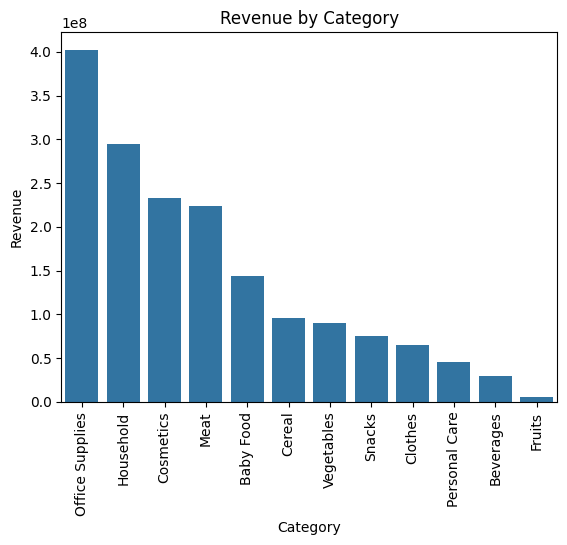

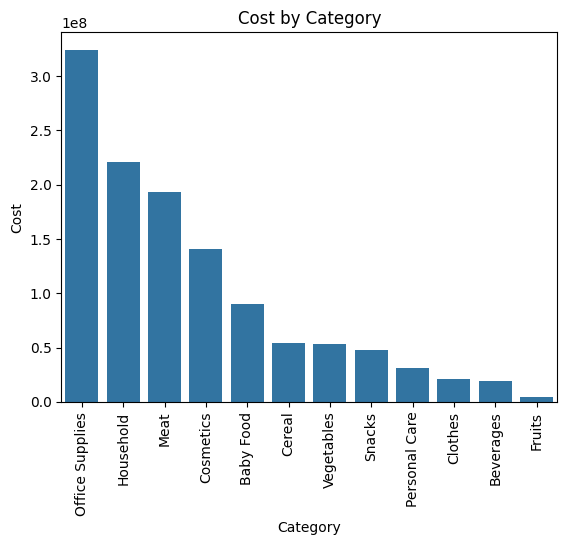

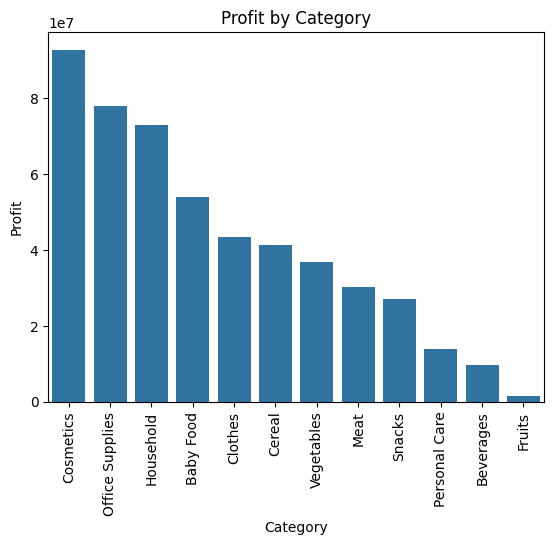

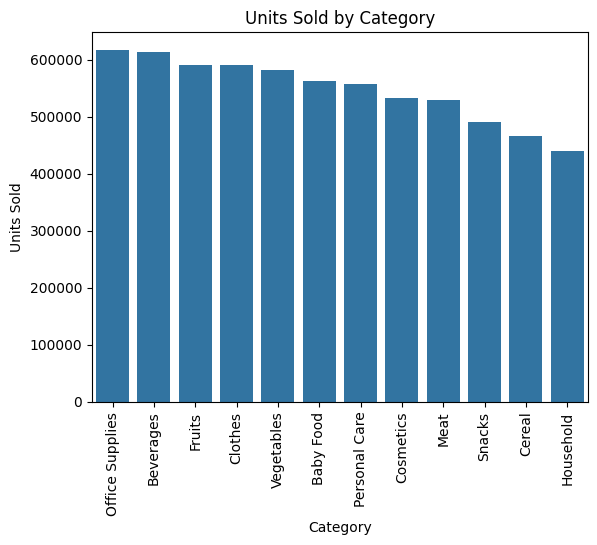

In [24]:
from pandas.core.indexes import category
# Sales by Product Category

category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Category")
plt.xticks(rotation=90)
plt.show()

category_cost = df.groupby("category")["cost"].sum().sort_values(ascending=False)

sns.barplot(x=category_cost.index, y=category_cost.values)
plt.xlabel("Category")
plt.ylabel("Cost")
plt.title("Cost by Category")
plt.xticks(rotation=90)
plt.show()

category_profit = df.groupby("category")["profit"].sum().sort_values(ascending=False)

sns.barplot(x=category_profit.index, y=category_profit.values)
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category")
plt.xticks(rotation=90)
plt.show()

category_units_sold = df.groupby("category")["units_sold"].sum().sort_values(ascending=False)

sns.barplot(x=category_units_sold.index, y=category_units_sold.values)
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.title("Units Sold by Category")
plt.xticks(rotation=90)
plt.show()


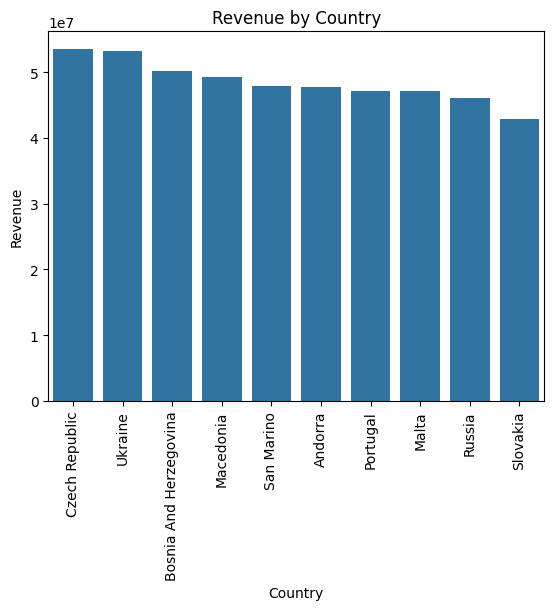

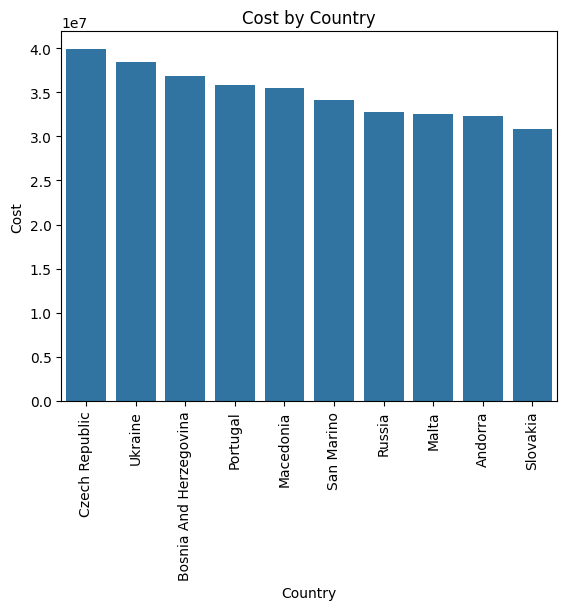

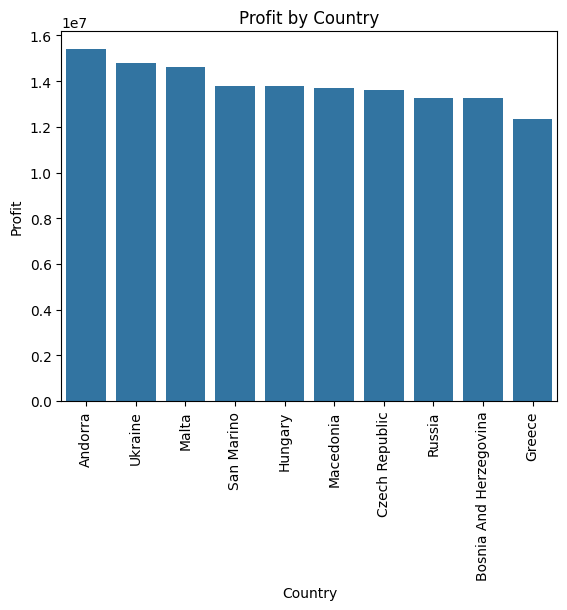

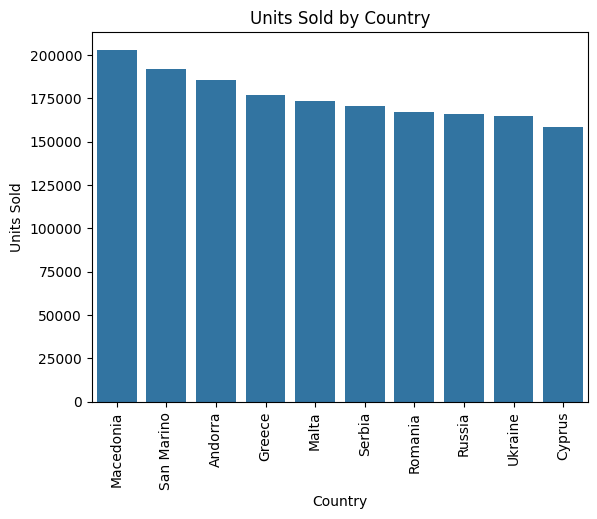

In [25]:
# Sales by Country

country_revenue = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

sns.barplot(x=country_revenue.head(10).index, y=country_revenue.head(10).values)
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Revenue by Country")
plt.xticks(rotation=90)
plt.show()

country_cost = df.groupby("country")["cost"].sum().sort_values(ascending=False)

sns.barplot(x=country_cost.head(10).index, y=country_cost.head(10).values)
plt.xlabel("Country")
plt.ylabel("Cost")
plt.title("Cost by Country")
plt.xticks(rotation=90)
plt.show()

country_profit = df.groupby("country")["profit"].sum().sort_values(ascending=False)

sns.barplot(x=country_profit.head(10).index, y=country_profit.head(10).values)
plt.xlabel("Country")
plt.ylabel("Profit")
plt.title("Profit by Country")
plt.xticks(rotation=90)
plt.show()

country_units_sold = df.groupby("country")["units_sold"].sum().sort_values(ascending=False)

sns.barplot(x=country_units_sold.head(10).index, y=country_units_sold.head(10).values)
plt.xlabel("Country")
plt.ylabel("Units Sold")
plt.title("Units Sold by Country")
plt.xticks(rotation=90)
plt.show()

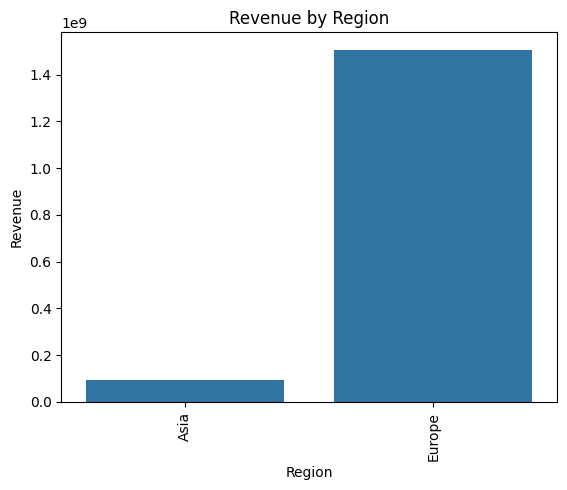

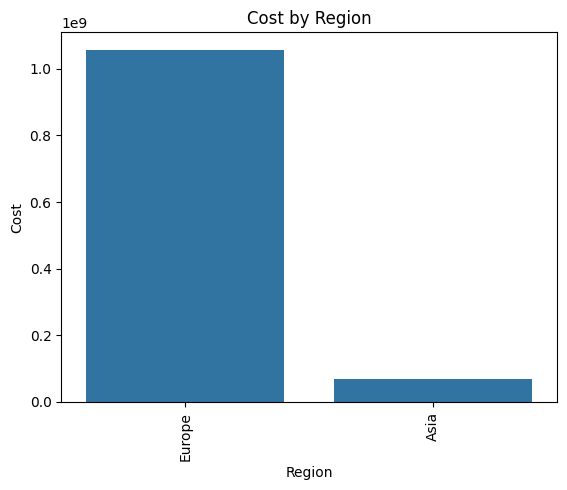

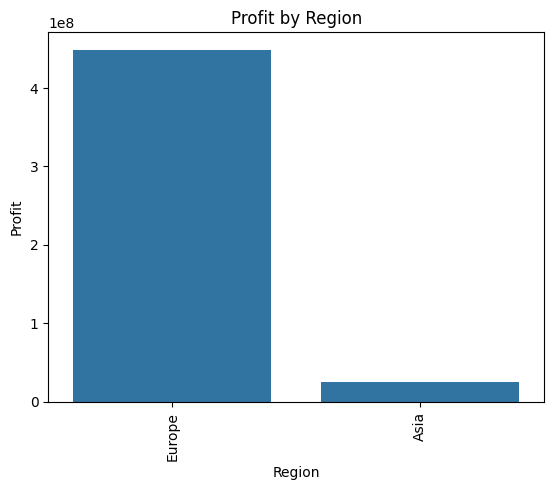

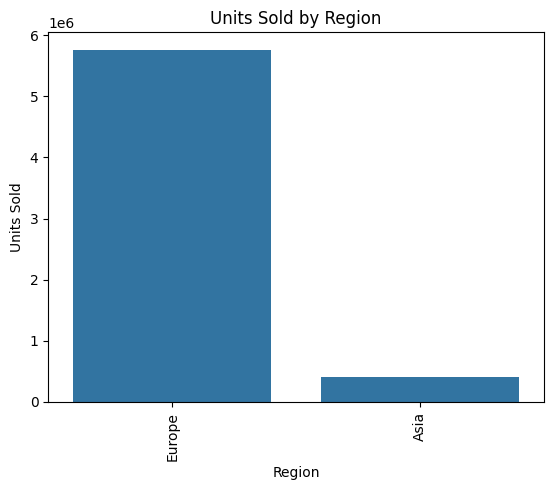

In [26]:
# Sales by Region

region_revenue = df.groupby("region")["revenue"].sum().sort_values()

sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.title("Revenue by Region")
plt.xticks(rotation=90)
plt.show()

region_cost = df.groupby("region")["cost"].sum().sort_values(ascending=False)

sns.barplot(x=region_cost.index, y=region_cost.values)
plt.xlabel("Region")
plt.ylabel("Cost")
plt.title("Cost by Region")
plt.xticks(rotation=90)
plt.show()

region_profit = df.groupby("region")["profit"].sum().sort_values(ascending=False)

sns.barplot(x=region_profit.index, y=region_profit.values)
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Profit by Region")
plt.xticks(rotation=90)
plt.show()

region_units_sold = df.groupby("region")["units_sold"].sum().sort_values(ascending=False)

sns.barplot(x=region_units_sold.index, y=region_units_sold.values)
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.title("Units Sold by Region")
plt.xticks(rotation=90)
plt.show()

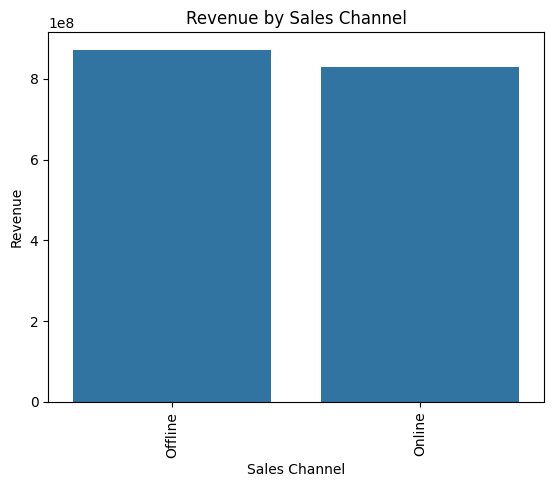

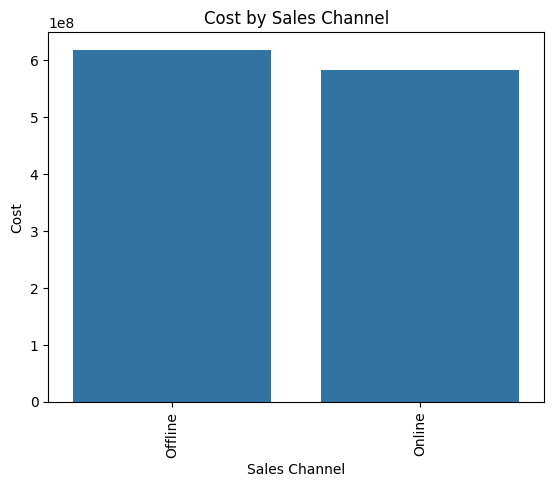

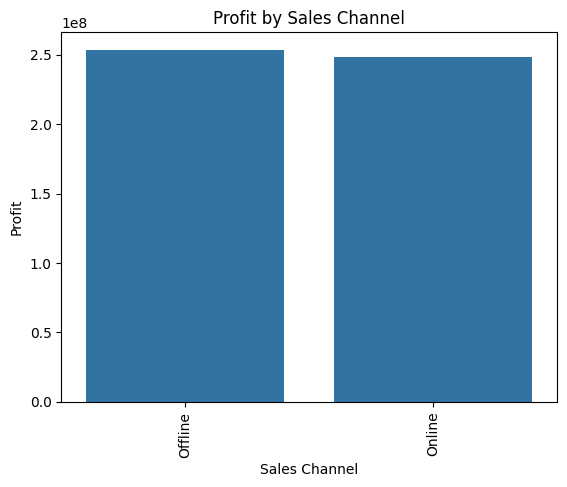

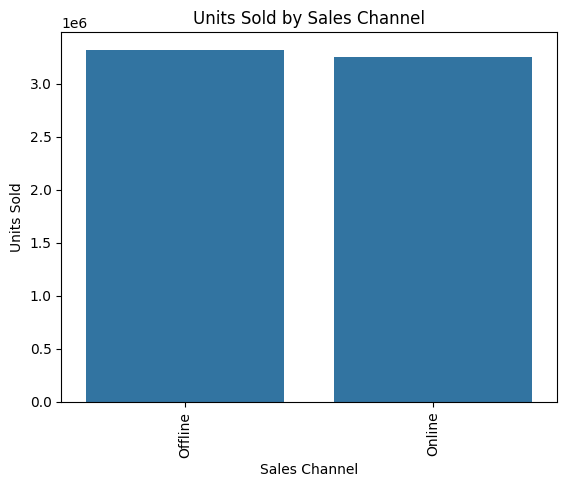

In [27]:
# Sales by Sales Channel

channel_revenue = df.groupby("sales_channel")["revenue"].sum()

sns.barplot(x=channel_revenue.index, y=channel_revenue.values)
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.title("Revenue by Sales Channel")
plt.xticks(rotation=90)
plt.show()

channel_cost = df.groupby("sales_channel")["cost"].sum()

sns.barplot(x=channel_cost.index, y=channel_cost.values)
plt.xlabel("Sales Channel")
plt.ylabel("Cost")
plt.title("Cost by Sales Channel")
plt.xticks(rotation=90)
plt.show()

channel_profit = df.groupby("sales_channel")["profit"].sum()

sns.barplot(x=channel_profit.index, y=channel_profit.values)
plt.xlabel("Sales Channel")
plt.ylabel("Profit")
plt.title("Profit by Sales Channel")
plt.xticks(rotation=90)
plt.show()

channel_units_sold = df.groupby("sales_channel")["units_sold"].sum()

sns.barplot(x=channel_units_sold.index, y=channel_units_sold.values)
plt.xlabel("Sales Channel")
plt.ylabel("Units Sold")
plt.title("Units Sold by Sales Channel")
plt.xticks(rotation=90)
plt.show()


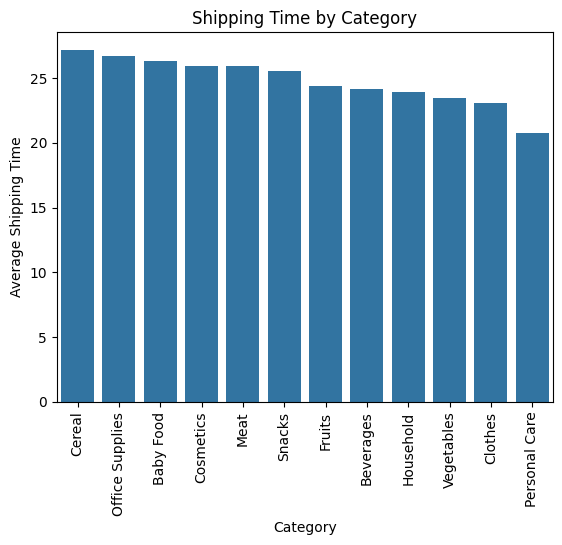

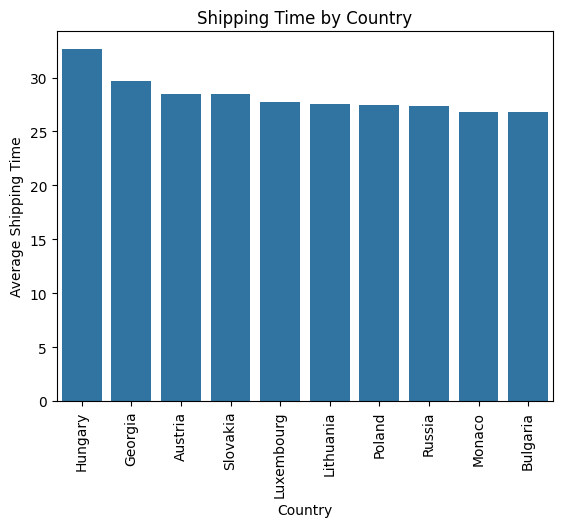

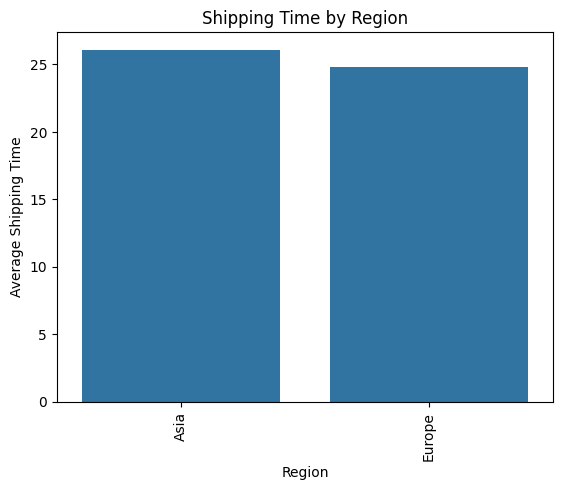

In [28]:
# Order-to-shipment lead time analysis

df["shipping_time"].describe()

shipping_category = (df.groupby("category")["shipping_time"].mean().sort_values(ascending=False))

sns.barplot(x=shipping_category.index, y=shipping_category.values)
plt.xlabel("Category")
plt.ylabel("Average Shipping Time")
plt.title("Shipping Time by Category")
plt.xticks(rotation=90)
plt.show()

shipping_country = (df.groupby("country")["shipping_time"].mean().sort_values(ascending=False))

sns.barplot(x=shipping_country.head(10).index, y=shipping_country.head(10).values)
plt.xlabel("Country")
plt.ylabel("Average Shipping Time")
plt.title("Shipping Time by Country")
plt.xticks(rotation=90)
plt.show()

shipping_region = (df.groupby("region")["shipping_time"].mean().sort_values(ascending=False))

sns.barplot(x=shipping_region.index, y=shipping_region.values)
plt.xlabel("Region")
plt.ylabel("Average Shipping Time")
plt.title("Shipping Time by Region")
plt.xticks(rotation=90)
plt.show()

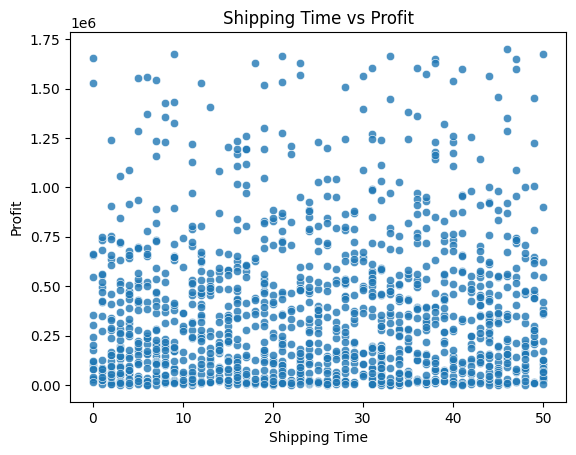

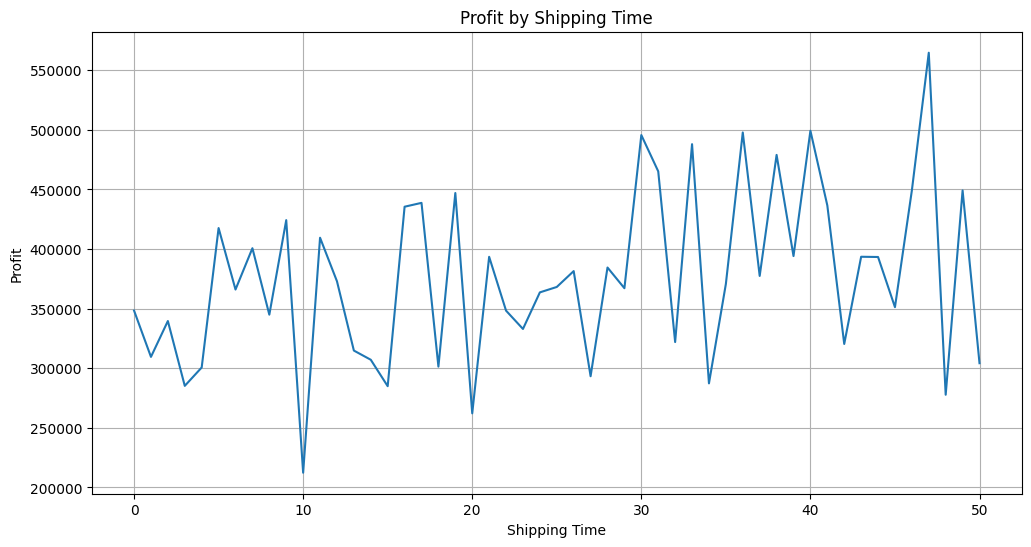

In [29]:
# Correlation between profit and shipment lead time

df[["shipping_time", "profit"]].corr()

sns.scatterplot(x="shipping_time", y="profit", data=df, alpha=0.8)
plt.xlabel("Shipping Time")
plt.ylabel("Profit")
plt.title("Shipping Time vs Profit")
plt.show()

shipping_profit = df.groupby("shipping_time")["profit"].mean()

plt.figure(figsize=(12,6))

sns.lineplot(x=shipping_profit.index, y=shipping_profit.values)
plt.xlabel("Shipping Time")
plt.ylabel("Profit")
plt.title("Profit by Shipping Time")
plt.grid(True)
plt.show()

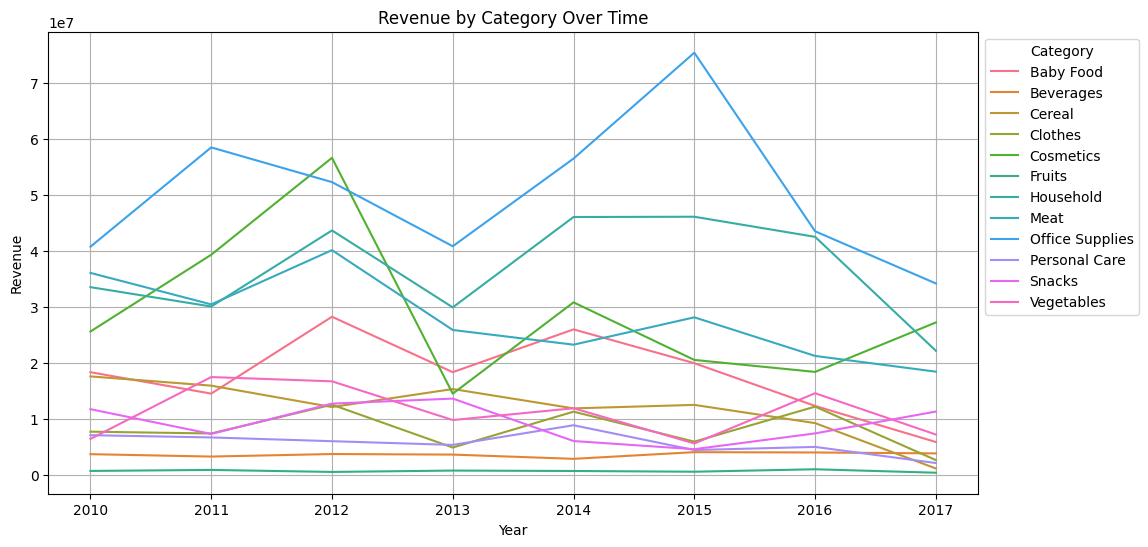

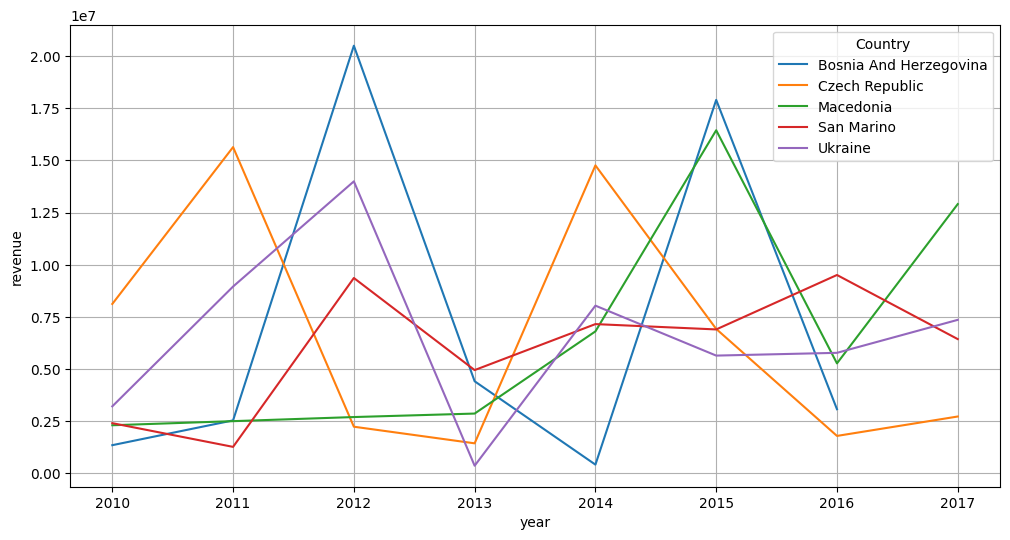

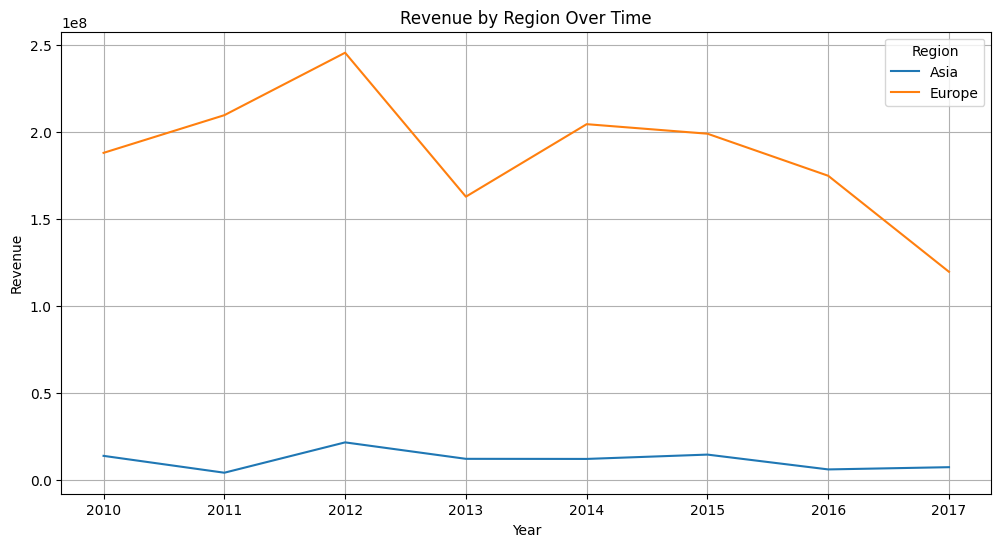

In [30]:
# Sales dynamics and trends analysis

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

category_time = (df.groupby(["year" , "category"])["revenue"].sum().reset_index())

plt.figure(figsize=(12,6))

sns.lineplot(data=category_time, x="year", y="revenue", hue="category")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Revenue by Category Over Time")
plt.legend(title="Category", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

top_countries = df.groupby("country")["revenue"].sum().nlargest(5).index
top_countries = df[df["country"].isin(top_countries)]

top_countries = (top_countries.groupby(["year", "country"])["revenue"].sum().reset_index())

plt.figure(figsize=(12,6))

sns.lineplot(data=top_countries, x="year", y="revenue", hue="country")
plt.legend(title="Country", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

region_time = (df.groupby(["year" , "region"])["revenue"].sum().reset_index())

plt.figure(figsize=(12,6))

sns.lineplot(data=region_time, x="year", y="revenue", hue="region")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Revenue by Region Over Time")
plt.legend(title="Region", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

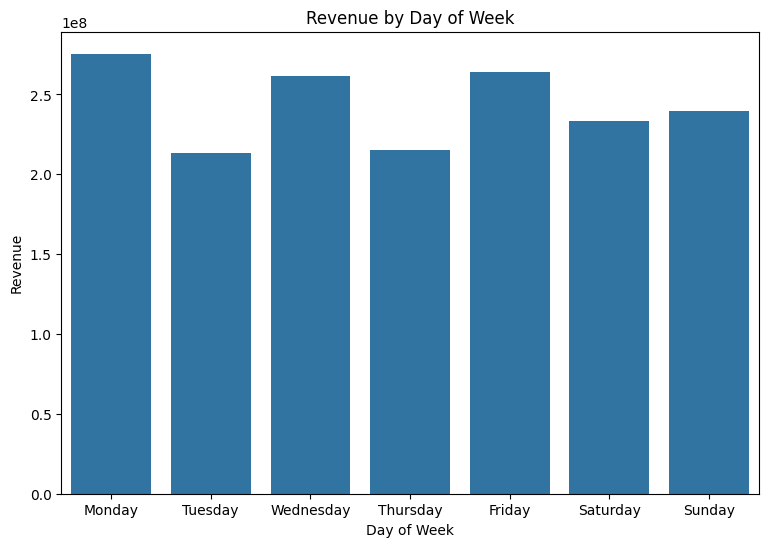

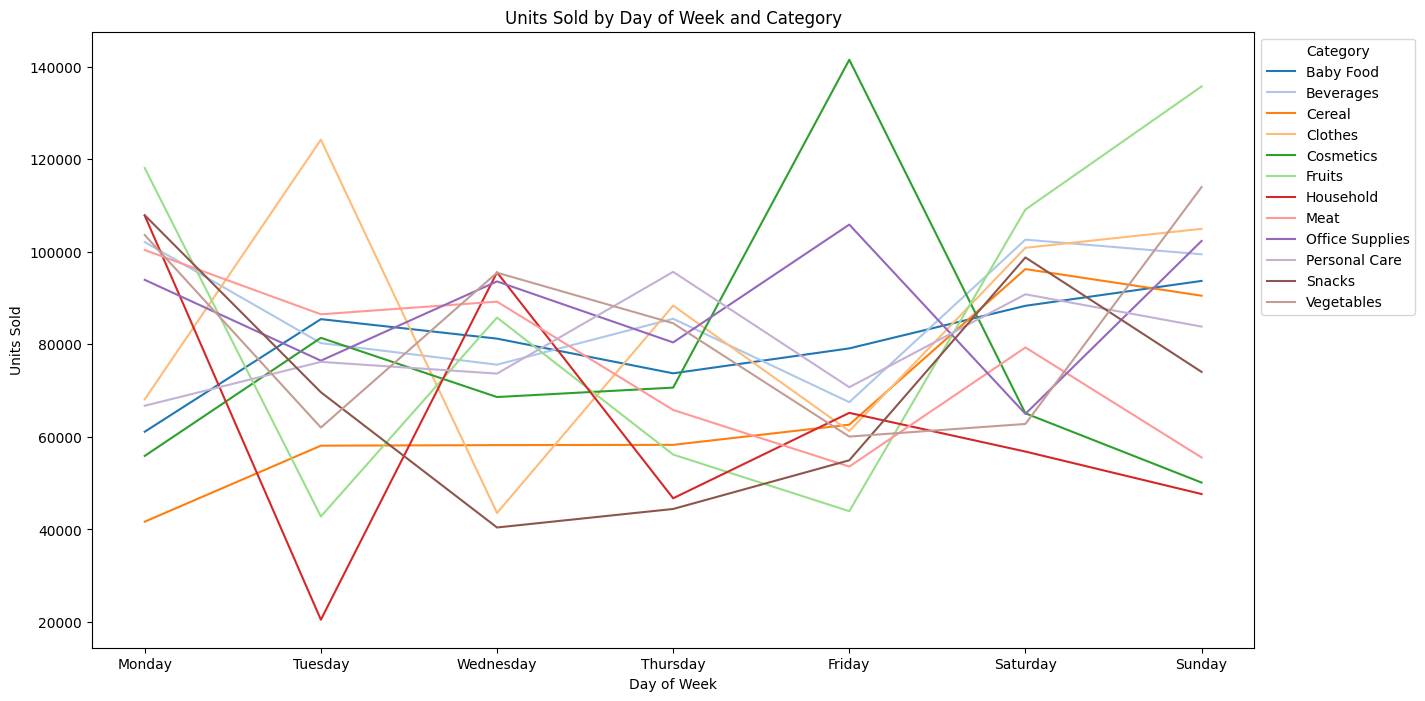

In [31]:
# Product sales by day of the week

df["day_name"] = df["order_date"].dt.day_name()

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_revenue = df.groupby("day_name")["revenue"].sum().reindex(days)

plt.figure(figsize=(9,6))

sns.barplot(x=day_revenue.index, y=day_revenue.values)
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.title("Revenue by Day of Week")
plt.show()

day_category = df.groupby(["day_name", "category"])["units_sold"].sum().reset_index()

day_category["day_name"] = pd.Categorical(day_category["day_name"], categories=days,ordered=True)

palette = sns.color_palette("tab20", 12)

plt.figure(figsize=(15,8))
sns.lineplot(data=day_category, x="day_name", y="units_sold", hue="category", palette=palette)
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.title("Units Sold by Day of Week and Category")
plt.legend(title="Category", bbox_to_anchor=(1, 1))
plt.show()

## **4. Conclusions & Recommendations:**

### Key Conclusions:
* **Financial Performance:** The company generated approximately \$1.7B in total revenue and \$500M in profit, demonstrating strong operational profitability during the analyzed period.
* **Geographic Focus:** Europe represents the primary operating market, accounting for the vast majority of overall revenue and net profit.
* **Product Dynamics:** Office Supplies generates the highest absolute revenue, whereas Cosmetics achieves the highest profitability, indicating a more favorable margin structure.
* **Sales Channels:** Online and offline channels yield nearly identical results, making both equally critical to omnichannel business strategy.
* **Supply Chain Efficiency:** The average order fulfillment lead time is approximately 25 days. Correlation analysis confirmed no meaningful link between shipping duration and transaction profit.
* **Historical Trends:** Peak sales performance was recorded in 2012, followed by a continuous downward trend that requires further root-cause analysis.
* **Weekly Seasonality:** Sales volume is evenly distributed across all days of the week, displaying no distinct weekly seasonality pattern.

---

### Strategic Recommendations:
* **Margin Optimization:** Increase investment and marketing efforts in the Cosmetics category to maximize high-margin returns.
* **Omnichannel Strategy:** Maintain balanced support for both online and offline channels, as both show equivalent performance and reach.
* **Performance Recovery:** Investigate the post-2012 sales decline by analyzing market trends, competitive shifts, and product lifecycle changes.
* **Logistics Streamlining:** Audit supply chain processes for categories with the longest fulfillment lead times to identify process optimization opportunities.
* **Geographic Expansion:** Evaluate market expansion opportunities outside Europe, particularly in underrepresented regions with untapped growth potential.

---

### Executive Summary:
This comprehensive analysis evaluated the company's performance across product hierarchies, geographic markets, sales channels, and historical timelines. The key findings pinpoint the core drivers of revenue and margin performance while highlighting strategic leverage points for operational improvement and long-term business growth.